# What Do They Talk About? Content Analysis: Trump vs AOC
## Examining Language, Topics, and Digital Identity

In this notebook, we look at **what** Trump and AOC actually say in their tweets and **how** they say it. This is a key part of **netnography** — the study of online communities and cultures. By analyzing the words politicians choose, the hashtags they use, and the topics they focus on, we can understand how they build their public image and connect with their audiences on social media.

**Why does language matter in politics?** Every word a politician types is a choice. Using ALL CAPS signals urgency or anger. Choosing certain hashtags signals belonging to a movement. Mentioning other politicians builds alliances or picks fights. By studying these patterns systematically, we move beyond gut feelings and into evidence-based analysis of political communication.

**What you will learn in this notebook:**
1. How Trump and AOC differ in writing style (length, punctuation, capitalization)
2. What words each politician uses most — and which words are unique to each
3. How hashtags serve as identity markers and rallying cries
4. Who each politician mentions and what that reveals about their networks
5. What topics dominate each politician's feed
6. A visual "map" of all tweets showing how AI understands the meaning of each message

In [1]:
# --- Setup: imports and configuration ---

import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from utils.data_loader import load_tweets
from utils.plot_helpers import (
    setup_style, get_colors, get_user_label,
    comparative_bar, comparative_hist, format_large_numbers
)
from utils.text_helpers import (
    extract_hashtags, extract_mentions, clean_text,
    get_word_frequencies, get_stopwords
)
from config import (
    FIGURE_SIZE, FIGURE_SIZE_SMALL, FIGURE_SIZE_LARGE,
    RANDOM_SEED, TARGET_USERS
)

# Apply consistent style
setup_style()
colors = get_colors()
np.random.seed(RANDOM_SEED)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

print('Setup complete.')

Setup complete.


In [2]:
# --- Load data ---

df = load_tweets()

print(f"Total tweets loaded: {df.shape[0]}")
print(f"Tweets per user: {df['user'].value_counts().to_dict()}")
print(f"Date range: {df['created_at'].min()} to {df['created_at'].max()}")

Loaded 200 tweets from processed/
Total tweets loaded: 200
Tweets per user: {'aoc': 100, 'trump': 100}
Date range: 2025-04-01 20:53:05+00:00 to 2026-02-26 15:32:57+00:00


---
## 1. How Do They Write? Comparing Writing Styles

Before we look at *what* they say, let's look at *how* they say it. Writing style reveals a lot about a person's communication strategy:

- **Tweet length** tells us whether someone writes short, punchy statements or longer, more detailed messages.
- **Capitalization (CAPS)** can signal shouting, emphasis, or emotional intensity.
- **Punctuation** like exclamation marks (!) suggest excitement or urgency, while question marks (?) can indicate curiosity or rhetorical challenges.
- **Emoji usage** shows how informal or expressive someone is online.

**Key terms:**
- **Mean (average):** Add up all values and divide by how many there are. If 5 tweets have lengths of 10, 20, 30, 40, and 50 characters, the mean is 30.
- **Median (middle value):** Line up all values from smallest to largest and pick the one in the middle. Less affected by extreme values than the mean.
- **Standard deviation (spread):** How spread out the values are. A small spread means most tweets are similar in length; a large spread means they vary a lot.

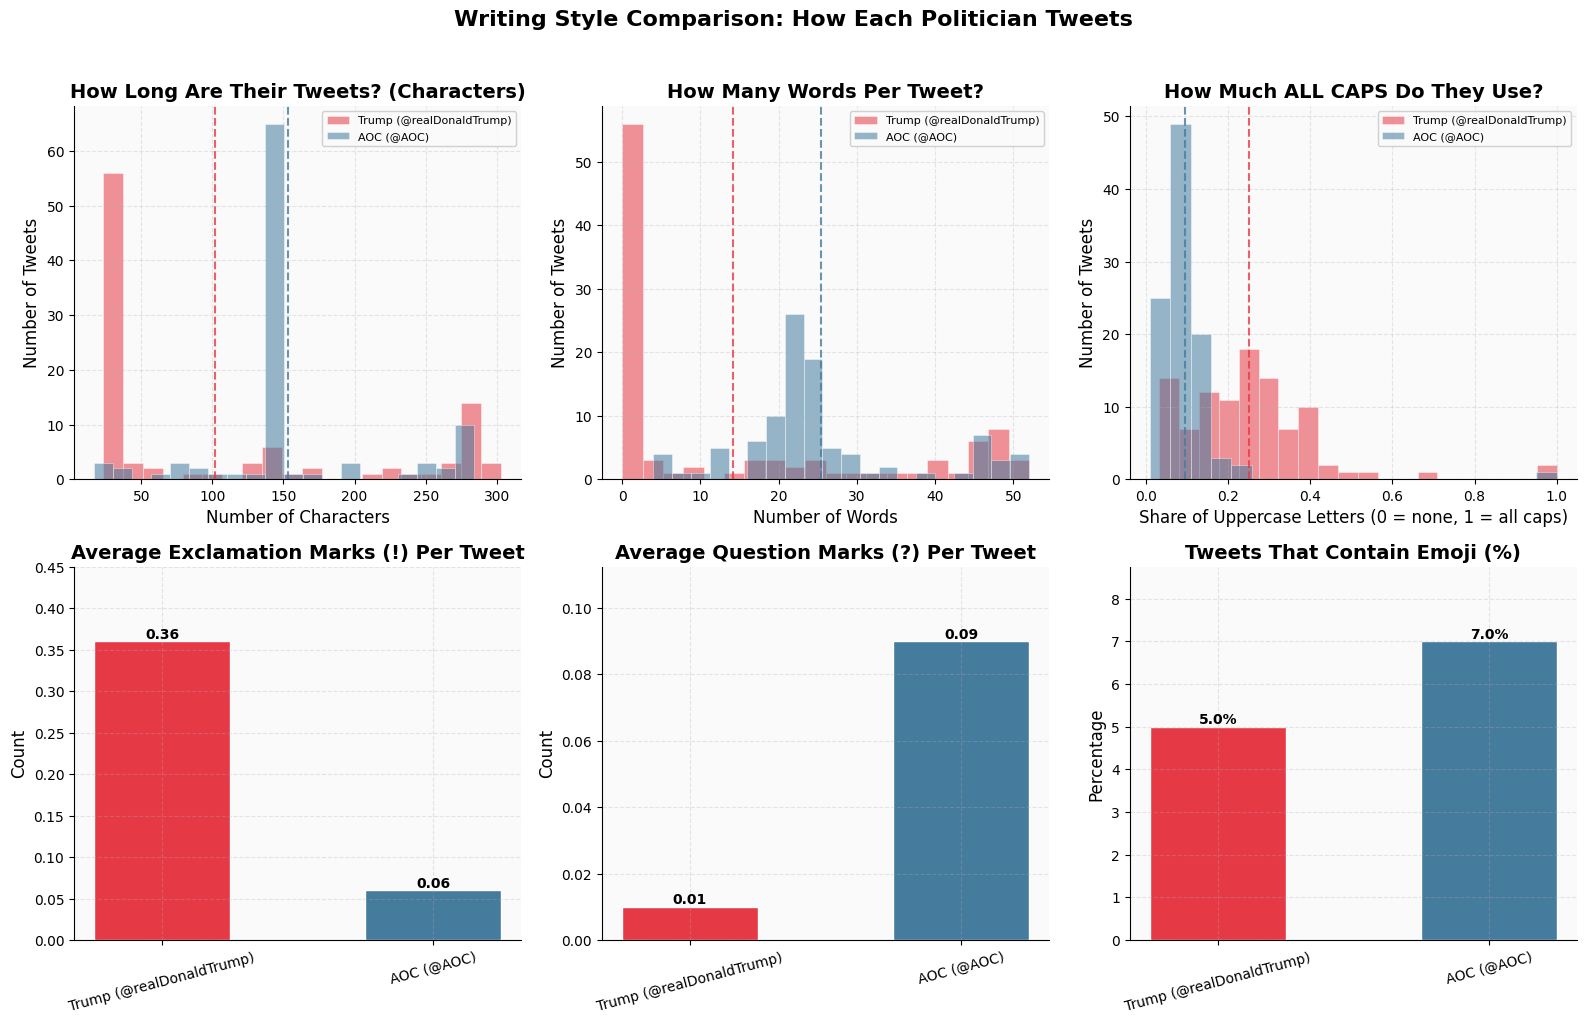


Writing Style Summary (numbers rounded to 2 decimal places):
      text_length                word_count               caps_ratio        exclamation_count     question_count    
             mean median     std       mean median    std       mean median              mean sum           mean sum
user                                                                                                                
aoc        153.31  140.0   59.51      25.39   23.0  10.99       0.10   0.08              0.06   6           0.09   9
trump      102.03   23.0  105.51      14.14    0.0  19.00       0.25   0.24              0.36  36           0.01   1


In [3]:
# --- Writing style comparison: 2x3 chart grid ---

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- Row 1: How values are spread out ---

# 1. How long are their tweets? (in characters)
ax = axes[0, 0]
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['text_length'].dropna()
    ax.hist(user_data, bins=20, alpha=0.55, color=colors[user],
            edgecolor='white', linewidth=0.5, label=get_user_label(user))
    mean_val = user_data.mean()
    ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('How Long Are Their Tweets? (Characters)', fontweight='bold')
ax.set_xlabel('Number of Characters')
ax.set_ylabel('Number of Tweets')
ax.legend(fontsize=8)

# 2. How many words per tweet?
ax = axes[0, 1]
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['word_count'].dropna()
    ax.hist(user_data, bins=20, alpha=0.55, color=colors[user],
            edgecolor='white', linewidth=0.5, label=get_user_label(user))
    mean_val = user_data.mean()
    ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('How Many Words Per Tweet?', fontweight='bold')
ax.set_xlabel('Number of Words')
ax.set_ylabel('Number of Tweets')
ax.legend(fontsize=8)

# 3. How much do they use ALL CAPS?
ax = axes[0, 2]
for user in ['trump', 'aoc']:
    user_data = df[df['user'] == user]['caps_ratio'].dropna()
    ax.hist(user_data, bins=20, alpha=0.55, color=colors[user],
            edgecolor='white', linewidth=0.5, label=get_user_label(user))
    mean_val = user_data.mean()
    ax.axvline(mean_val, color=colors[user], linestyle='--', linewidth=1.5, alpha=0.8)
ax.set_title('How Much ALL CAPS Do They Use?', fontweight='bold')
ax.set_xlabel('Share of Uppercase Letters (0 = none, 1 = all caps)')
ax.set_ylabel('Number of Tweets')
ax.legend(fontsize=8)

# --- Row 2: Average values compared side by side ---

# 4. Average exclamation marks per tweet
ax = axes[1, 0]
users = ['trump', 'aoc']
exc_means = [df[df['user'] == u]['exclamation_count'].mean() for u in users]
user_labels = [get_user_label(u) for u in users]
bars = ax.bar(user_labels, exc_means, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, exc_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Average Exclamation Marks (!) Per Tweet', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(exc_means) * 1.25 if max(exc_means) > 0 else 1)
ax.tick_params(axis='x', rotation=15)

# 5. Average question marks per tweet
ax = axes[1, 1]
q_means = [df[df['user'] == u]['question_count'].mean() for u in users]
bars = ax.bar(user_labels, q_means, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, q_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Average Question Marks (?) Per Tweet', fontweight='bold')
ax.set_ylabel('Count')
ax.set_ylim(0, max(q_means) * 1.25 if max(q_means) > 0 else 1)
ax.tick_params(axis='x', rotation=15)

# 6. What percentage of tweets contain emoji?
ax = axes[1, 2]
emoji_pcts = [df[df['user'] == u]['has_emoji'].mean() * 100 for u in users]
bars = ax.bar(user_labels, emoji_pcts, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, emoji_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Tweets That Contain Emoji (%)', fontweight='bold')
ax.set_ylabel('Percentage')
ax.set_ylim(0, max(emoji_pcts) * 1.25 if max(emoji_pcts) > 0 else 10)
ax.tick_params(axis='x', rotation=15)

fig.suptitle('Writing Style Comparison: How Each Politician Tweets',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary statistics table
print("\nWriting Style Summary (numbers rounded to 2 decimal places):")
text_stats = df.groupby('user').agg({
    'text_length': ['mean', 'median', 'std'],
    'word_count': ['mean', 'median', 'std'],
    'caps_ratio': ['mean', 'median'],
    'exclamation_count': ['mean', 'sum'],
    'question_count': ['mean', 'sum'],
}).round(2)
print(text_stats.to_string())

**What does this tell us?**

The charts above reveal each politician's "digital voice." Look at the dashed lines in the top row — those show the average for each user. When one dashed line is far to the right of the other, it means that person consistently writes longer (or shorter) tweets.

The bottom row compares specific style markers. High exclamation mark usage suggests a more dramatic, urgent tone — the digital equivalent of speaking loudly. Question marks can indicate engagement with the audience ("Don't you agree?") or rhetorical challenges to opponents. Emoji usage signals informality and emotional expressiveness.

In netnography, these patterns are not just numbers — they are clues to how each politician wants to be perceived online.

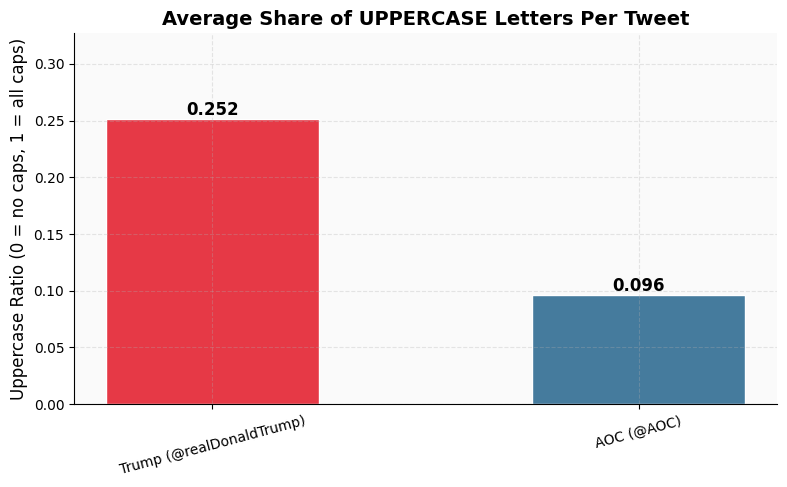


EXAMPLES: Tweets with the most ALL CAPS

--- Trump (@realDonaldTrump) ---
  1. [caps ratio=1.000] THE SUPREME COURT IS BEING PLAYED BY THE RADICAL LEFT LOSERS, WHO HAVE NO SUPPORT, THE PUBLIC HATES THEM, AND THEIR ONLY...
  2. [caps ratio=0.973] REPUBLICANS MUST DEFUND AND TOTALLY DISASSOCIATE THEMSELVES FROM NPR &amp; PBS, THE RADICAL LEFT “MONSTERS” THAT SO BADL...
  3. [caps ratio=0.707] TO MY GREAT FELLOW AMERICANS… https://t.co/oRsrE5TTHr

--- AOC (@AOC) ---
  1. [caps ratio=1.000] ALYSA LIU OH MY GOODNESS! 😭 🇺🇸
  2. [caps ratio=0.236] RT @EdKrassen: BREAKING:  @AOC just completely went off on Trump after ICE murdered Alex Pretti.  

"Donald Trump [is] a...
  3. [caps ratio=0.217] RT @MichaelSteele: This part.


In [4]:
# --- Closer look at ALL CAPS usage ---

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)

users = ['trump', 'aoc']
caps_means = [df[df['user'] == u]['caps_ratio'].mean() for u in users]
user_labels = [get_user_label(u) for u in users]

bars = ax.bar(user_labels, caps_means, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, caps_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Average Share of UPPERCASE Letters Per Tweet', fontweight='bold', fontsize=14)
ax.set_ylabel('Uppercase Ratio (0 = no caps, 1 = all caps)')
ax.set_ylim(0, max(caps_means) * 1.3 if max(caps_means) > 0 else 0.5)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# Show actual examples of high-caps tweets
print("\n" + "=" * 80)
print("EXAMPLES: Tweets with the most ALL CAPS")
print("=" * 80)

for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user].nlargest(3, 'caps_ratio')
    label = get_user_label(user)
    print(f"\n--- {label} ---")
    for rank, (_, row) in enumerate(user_df.iterrows(), 1):
        text_preview = row['text'][:120] + '...' if len(str(row['text'])) > 120 else row['text']
        print(f"  {rank}. [caps ratio={row['caps_ratio']:.3f}] {text_preview}")

**What does this tell us?**

ALL CAPS on the internet is widely understood as "shouting." A higher caps ratio means more words are written in uppercase. If one politician consistently uses more ALL CAPS than the other, it suggests a more aggressive or emphatic communication style — they want certain words to hit harder.

Look at the example tweets above. Do the ALL CAPS words tend to be names, slogans, or emotional phrases? This tells us *what* each politician chooses to emphasize.

---
## 2. Most Common Words: What Do They Actually Say?

Now we move from *how* they write to *what* they write about. By counting the most common words in each politician's tweets, we can see their priorities at a glance.

**Important note:** We remove common English words (called "stop words") like "the," "is," "and," etc. These words appear in everyone's writing and don't tell us anything interesting. What remains are the meaningful, content-carrying words that reveal each person's focus.

**Why this matters for netnography:** Vocabulary is not neutral. The words a politician uses most often frame how their audience thinks about issues. Repeating words like "great" and "winning" creates a narrative of success, while words like "justice" and "rights" frame a narrative of social change.

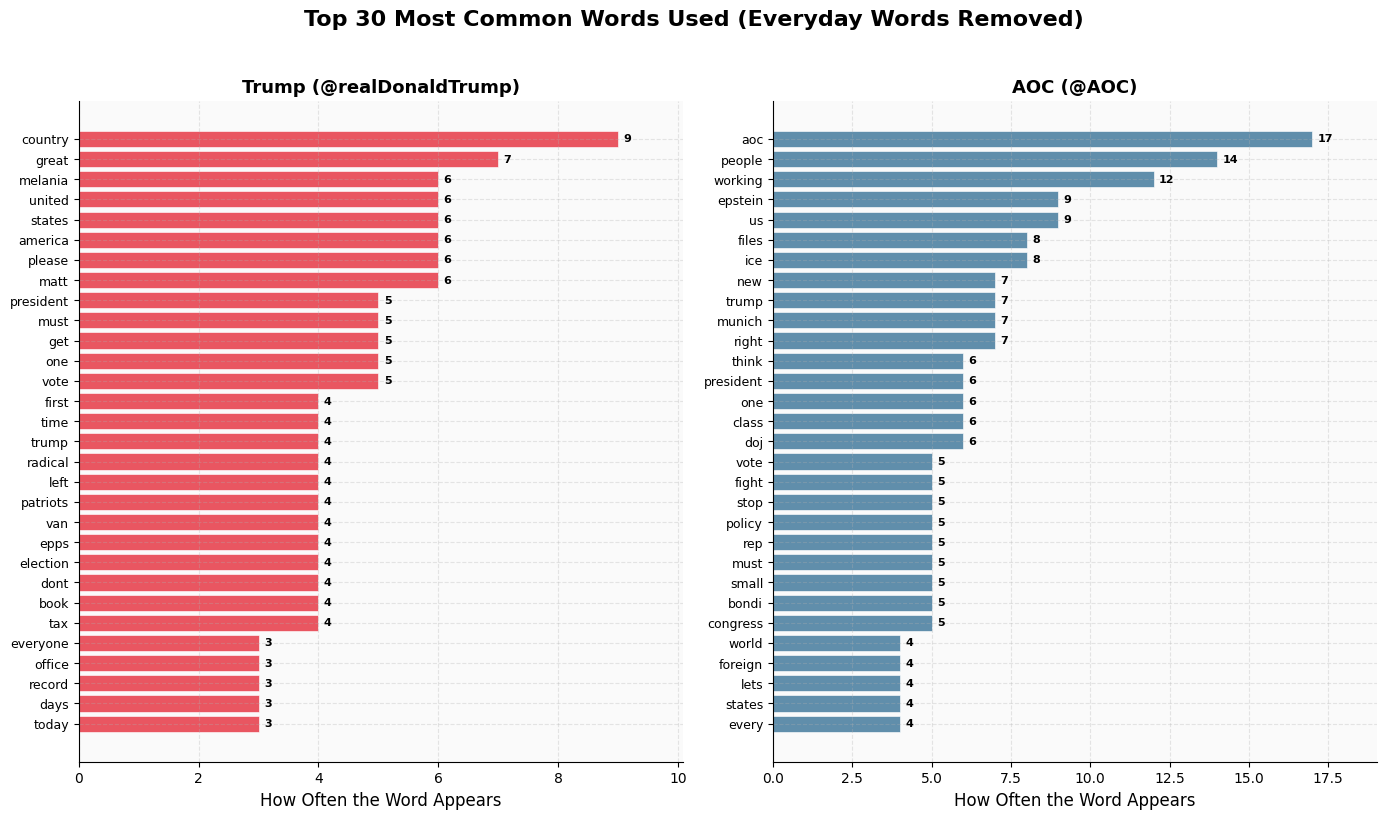

In [5]:
# --- Top 30 most common words for each user ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_texts = df[df['user'] == user]['text'].dropna().tolist()
    word_freqs = get_word_frequencies(user_texts, top_n=30)

    if word_freqs:
        words, counts = zip(*reversed(word_freqs))  # reversed for horizontal bar
        y_pos = np.arange(len(words))

        ax.barh(y_pos, counts, color=colors[user], alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)

        # Add count labels
        for i, count in enumerate(counts):
            ax.text(count + max(counts) * 0.01, i, str(count),
                    va='center', fontsize=8, fontweight='bold')

    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=13)
    ax.set_xlabel('How Often the Word Appears')
    ax.set_xlim(0, max(counts) * 1.12 if word_freqs else 10)

fig.suptitle('Top 30 Most Common Words Used (Everyday Words Removed)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What does this tell us?**

Compare the two lists side by side. The words that appear most are essentially each politician's "greatest hits" — the themes they return to again and again. Look for:
- **Self-references:** Does one politician mention their own name or brand more often?
- **Policy words:** Do you see words related to specific issues (economy, healthcare, immigration)?
- **Emotional words:** Are there words that carry strong feelings (great, terrible, fight, love)?
- **People words:** Do they reference "people," "Americans," "workers" — and what does that reveal about who they claim to represent?

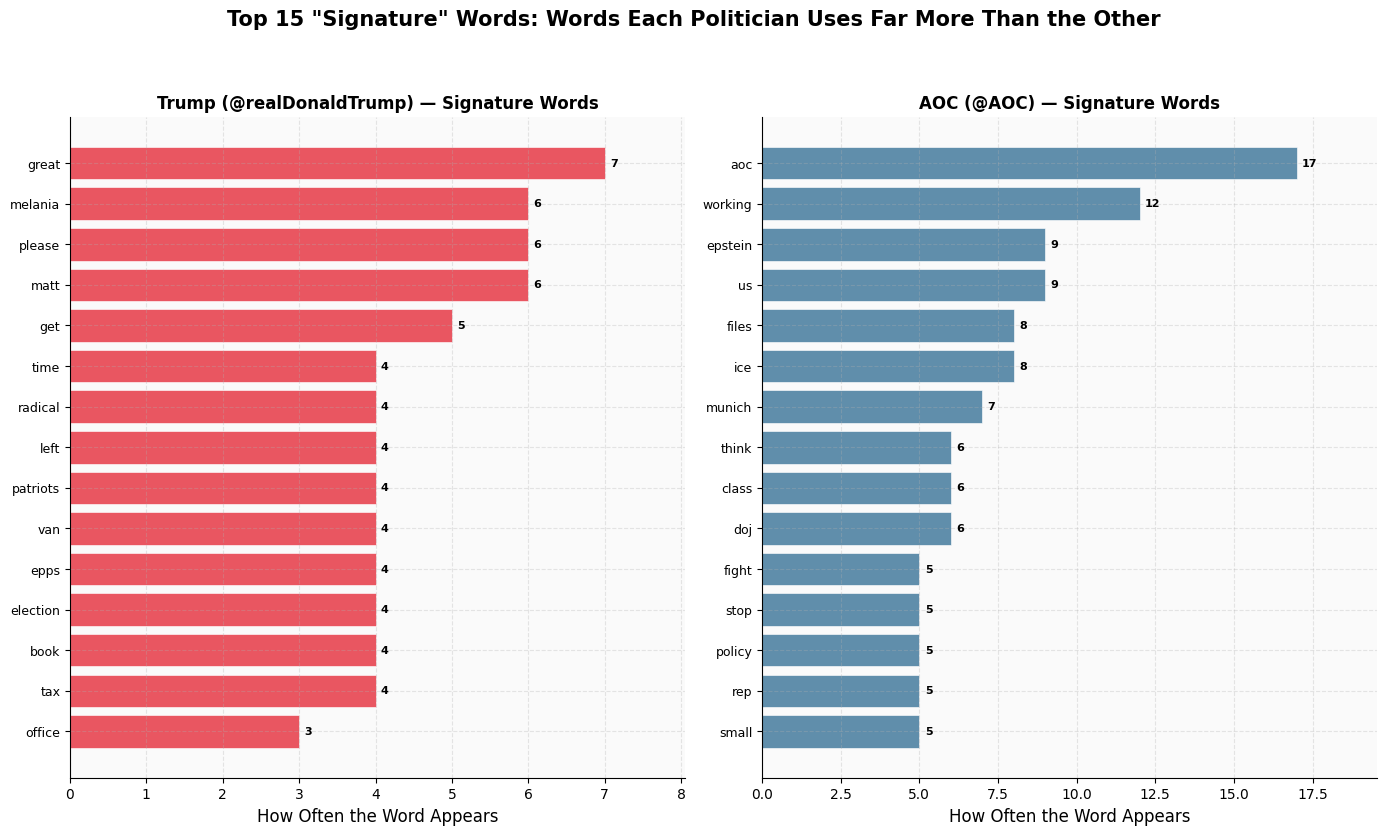


Signature vocabulary details:
(Distinctiveness score = how many times more this person uses the word compared to the other)

--- Trump (@realDonaldTrump) ---
  'great': used 7 times (distinctiveness score: 7.0x)
  'melania': used 6 times (distinctiveness score: 6.0x)
  'please': used 6 times (distinctiveness score: 6.0x)
  'matt': used 6 times (distinctiveness score: 6.0x)
  'get': used 5 times (distinctiveness score: 5.0x)
  'time': used 4 times (distinctiveness score: 4.0x)
  'radical': used 4 times (distinctiveness score: 4.0x)
  'left': used 4 times (distinctiveness score: 4.0x)
  'patriots': used 4 times (distinctiveness score: 4.0x)
  'van': used 4 times (distinctiveness score: 4.0x)
  'epps': used 4 times (distinctiveness score: 4.0x)
  'election': used 4 times (distinctiveness score: 4.0x)
  'book': used 4 times (distinctiveness score: 4.0x)
  'tax': used 4 times (distinctiveness score: 4.0x)
  'office': used 3 times (distinctiveness score: 3.0x)

--- AOC (@AOC) ---
  'aoc': u

In [6]:
# --- Words unique to each politician: their "signature vocabulary" ---

# Get word counts for each user (larger set for comparison)
trump_texts = df[df['user'] == 'trump']['text'].dropna().tolist()
aoc_texts = df[df['user'] == 'aoc']['text'].dropna().tolist()

trump_freqs = dict(get_word_frequencies(trump_texts, top_n=200))
aoc_freqs = dict(get_word_frequencies(aoc_texts, top_n=200))

# Find distinctive words: words used much more by one person than the other
# "Distinctiveness score" = how many times more one person uses a word compared to the other
trump_distinctive = []
for word, count in trump_freqs.items():
    other_count = aoc_freqs.get(word, 0)
    score = count / (other_count + 1)
    if score >= 2 and count >= 3:  # at least 2x more often and used 3+ times
        trump_distinctive.append((word, count, score))

aoc_distinctive = []
for word, count in aoc_freqs.items():
    other_count = trump_freqs.get(word, 0)
    score = count / (other_count + 1)
    if score >= 2 and count >= 3:
        aoc_distinctive.append((word, count, score))

# Sort by distinctiveness and take top 15
trump_distinctive.sort(key=lambda x: x[2], reverse=True)
aoc_distinctive.sort(key=lambda x: x[2], reverse=True)
trump_top15 = trump_distinctive[:15]
aoc_top15 = aoc_distinctive[:15]

# Plot
fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, (user, data) in enumerate([('trump', trump_top15), ('aoc', aoc_top15)]):
    ax = axes[idx]
    if data:
        words = [d[0] for d in reversed(data)]
        counts = [d[1] for d in reversed(data)]
        y_pos = np.arange(len(words))

        ax.barh(y_pos, counts, color=colors[user], alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(words, fontsize=9)

        for i, count in enumerate(counts):
            ax.text(count + max(counts) * 0.01, i, str(count),
                    va='center', fontsize=8, fontweight='bold')

        ax.set_xlim(0, max(counts) * 1.15)
    else:
        ax.text(0.5, 0.5, 'No distinctive words found',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)

    ax.set_title(f'{get_user_label(user)} — Signature Words', fontweight='bold', fontsize=12)
    ax.set_xlabel('How Often the Word Appears')

fig.suptitle('Top 15 "Signature" Words: Words Each Politician Uses Far More Than the Other',
             fontsize=15, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

# Print details
print("\nSignature vocabulary details:")
print("(Distinctiveness score = how many times more this person uses the word compared to the other)")
for user, data in [('trump', trump_top15), ('aoc', aoc_top15)]:
    label = get_user_label(user)
    print(f"\n--- {label} ---")
    for word, count, score in data:
        print(f"  '{word}': used {count} times (distinctiveness score: {score:.1f}x)")

**What does this tell us?**

"Signature words" are the words that belong primarily to one politician's vocabulary. If Trump uses the word "deal" 50 times but AOC only uses it twice, that is a "Trump word." These signature words are like a fingerprint — they reveal each person's unique rhetorical identity.

Think about what these word choices signal to each politician's audience. A politician who frequently uses combative words is constructing an identity as a fighter; one who uses policy-specific words is positioning themselves as a policy expert.

---
## 3. Hashtag Analysis: Digital Rallying Cries

Hashtags serve multiple purposes in political communication:
- **Identity markers:** #MAGA or #GreenNewDeal signals which "team" you are on
- **Issue framing:** The hashtag chosen to describe an event shapes how people think about it
- **Community building:** Using the same hashtag as your supporters creates a sense of belonging
- **Amplification:** Hashtags help tweets reach people beyond your followers

In netnography, we pay close attention to hashtags because they are one of the most explicit ways people signal their identity and allegiances online.

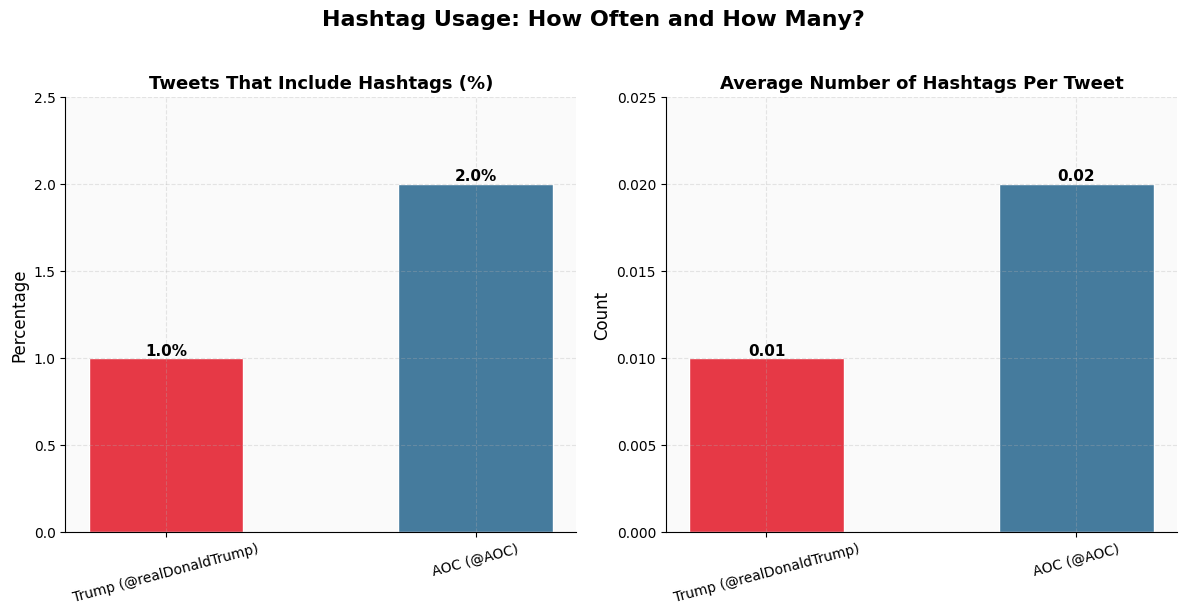

In [7]:
# --- How often do they use hashtags? ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

users = ['trump', 'aoc']
user_labels = [get_user_label(u) for u in users]

# 1. What percentage of tweets include at least one hashtag?
ax = axes[0]
hashtag_pcts = []
for u in users:
    user_data = df[df['user'] == u]
    pct = (user_data['hashtag_count'] > 0).mean() * 100
    hashtag_pcts.append(pct)

bars = ax.bar(user_labels, hashtag_pcts, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, hashtag_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Tweets That Include Hashtags (%)', fontweight='bold', fontsize=13)
ax.set_ylabel('Percentage')
ax.set_ylim(0, max(hashtag_pcts) * 1.25 if max(hashtag_pcts) > 0 else 10)
ax.tick_params(axis='x', rotation=15)

# 2. On average, how many hashtags per tweet?
ax = axes[1]
hashtag_means = [df[df['user'] == u]['hashtag_count'].mean() for u in users]
bars = ax.bar(user_labels, hashtag_means, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, hashtag_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Average Number of Hashtags Per Tweet', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(hashtag_means) * 1.25 if max(hashtag_means) > 0 else 1)
ax.tick_params(axis='x', rotation=15)

fig.suptitle('Hashtag Usage: How Often and How Many?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What does this tell us?**

If one politician uses hashtags much more than the other, it suggests different strategies for reaching audiences. Heavy hashtag users are trying to tap into trending conversations and movements. Politicians who rarely use hashtags may rely more on their existing follower base or on direct, unadorned statements that stand on their own.

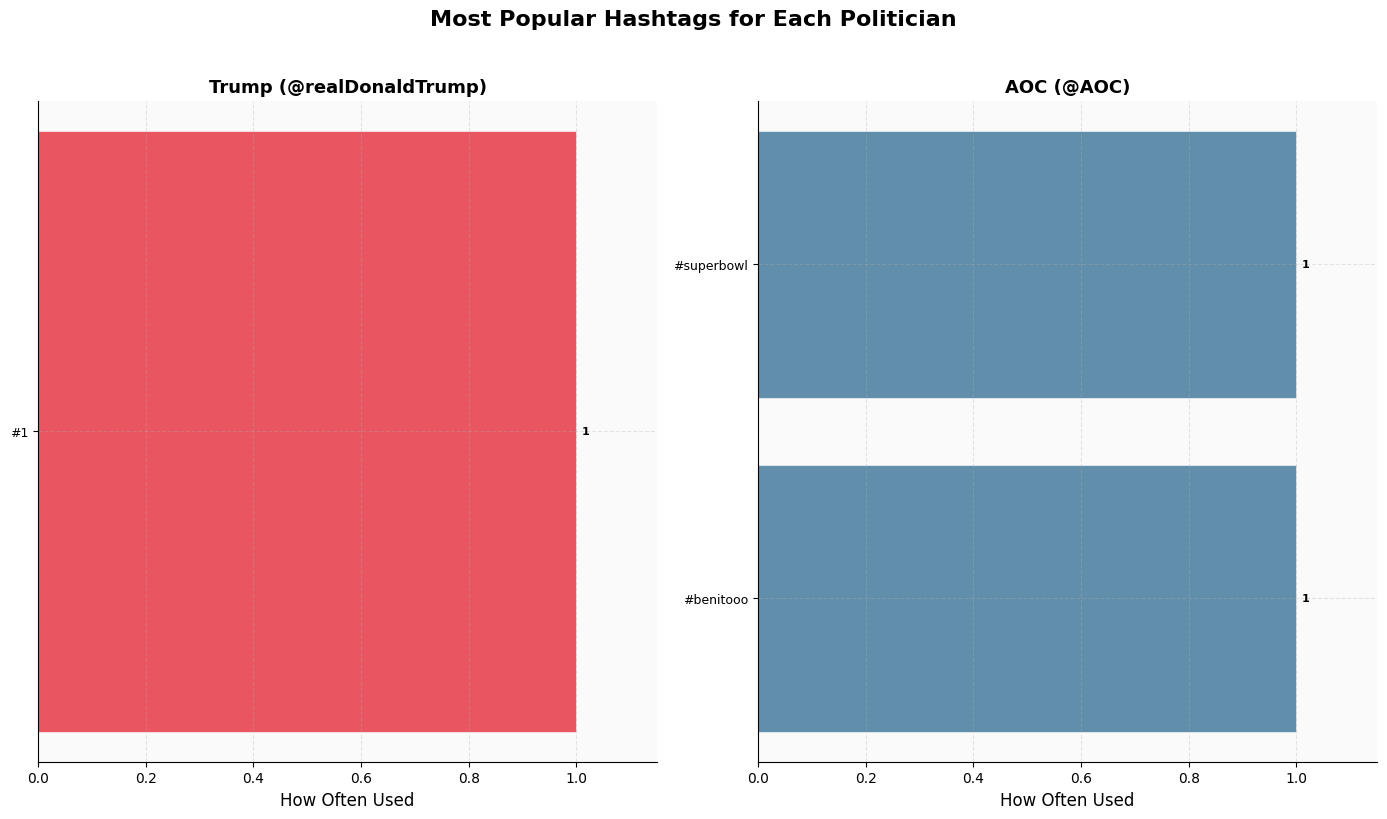

In [8]:
# --- What are their favorite hashtags? (Top 15 each) ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_df = df[df['user'] == user]

    # Extract all hashtags from the hashtags_extracted column
    all_hashtags = []
    for tags_str in user_df['hashtags_extracted'].dropna():
        if isinstance(tags_str, str):
            try:
                import ast
                tags = ast.literal_eval(tags_str)
                if isinstance(tags, list):
                    all_hashtags.extend([t.lower() for t in tags])
                else:
                    all_hashtags.append(str(tags).lower())
            except (ValueError, SyntaxError):
                for tag in tags_str.replace('[', '').replace(']', '').replace("'", '').split(','):
                    tag = tag.strip().lower()
                    if tag:
                        all_hashtags.append(tag)

    # Count and get top 15
    hashtag_counts = Counter(all_hashtags).most_common(15)

    if hashtag_counts:
        tags, counts = zip(*reversed(hashtag_counts))
        y_pos = np.arange(len(tags))

        ax.barh(y_pos, counts, color=colors[user], alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f'#{t}' for t in tags], fontsize=9)

        for i, count in enumerate(counts):
            ax.text(count + max(counts) * 0.01, i, str(count),
                    va='center', fontsize=8, fontweight='bold')

        ax.set_xlim(0, max(counts) * 1.15)
    else:
        ax.text(0.5, 0.5, 'No hashtags found',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)

    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=13)
    ax.set_xlabel('How Often Used')

fig.suptitle('Most Popular Hashtags for Each Politician',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What does this tell us?**

Each politician's top hashtags are essentially their "brand labels." Look at whether the hashtags are:
- **Personal branding** (their own name, campaign slogans)
- **Issue-based** (specific policy topics)
- **Movement-related** (broader political or social movements)
- **Reactive** (responding to current events)

The hashtags a politician chooses tell you what they want to be associated with in the public conversation.

HASHTAG OVERLAP ANALYSIS
Do Trump and AOC ever use the same hashtags?

Total unique hashtags used by Trump: 1
Total unique hashtags used by AOC:   2

Hashtags they BOTH use (0):
  None -- their hashtag worlds are completely separate.

Hashtags ONLY Trump uses (1):
  #1

Hashtags ONLY AOC uses (2):
  #benitooo
  #superbowl


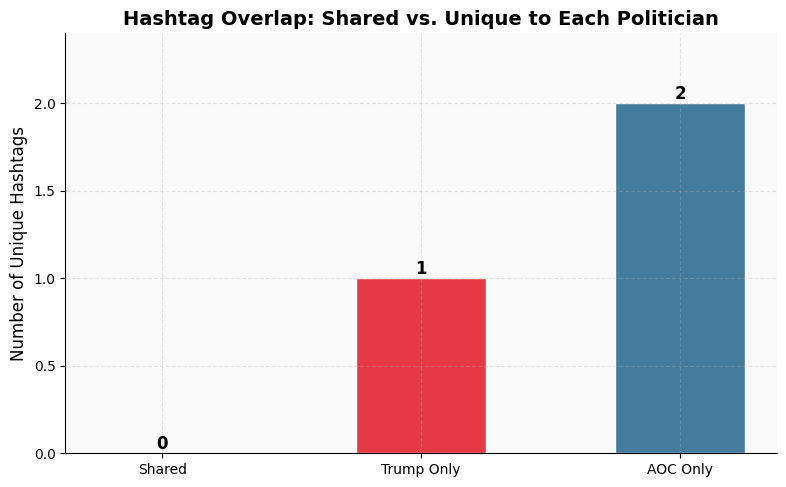

In [9]:
# --- Do they share any hashtags? Or are their hashtag worlds separate? ---

import ast

def extract_all_hashtags(user_df):
    """Extract all unique hashtags (lowercased) from a user's tweets."""
    all_tags = set()
    for tags_str in user_df['hashtags_extracted'].dropna():
        if isinstance(tags_str, str):
            try:
                tags = ast.literal_eval(tags_str)
                if isinstance(tags, list):
                    all_tags.update(t.lower() for t in tags)
                else:
                    all_tags.add(str(tags).lower())
            except (ValueError, SyntaxError):
                for tag in tags_str.replace('[', '').replace(']', '').replace("'", '').split(','):
                    tag = tag.strip().lower()
                    if tag:
                        all_tags.add(tag)
    return all_tags

trump_hashtags = extract_all_hashtags(df[df['user'] == 'trump'])
aoc_hashtags = extract_all_hashtags(df[df['user'] == 'aoc'])

shared = trump_hashtags & aoc_hashtags
trump_only = trump_hashtags - aoc_hashtags
aoc_only = aoc_hashtags - trump_hashtags

# Display results
print("=" * 70)
print("HASHTAG OVERLAP ANALYSIS")
print("Do Trump and AOC ever use the same hashtags?")
print("=" * 70)
print(f"\nTotal unique hashtags used by Trump: {len(trump_hashtags)}")
print(f"Total unique hashtags used by AOC:   {len(aoc_hashtags)}")
print(f"\nHashtags they BOTH use ({len(shared)}):")
if shared:
    for tag in sorted(shared):
        print(f"  #{tag}")
else:
    print("  None -- their hashtag worlds are completely separate.")

print(f"\nHashtags ONLY Trump uses ({len(trump_only)}):")
for tag in sorted(list(trump_only)[:20]):
    print(f"  #{tag}")
if len(trump_only) > 20:
    print(f"  ... and {len(trump_only) - 20} more")

print(f"\nHashtags ONLY AOC uses ({len(aoc_only)}):")
for tag in sorted(list(aoc_only)[:20]):
    print(f"  #{tag}")
if len(aoc_only) > 20:
    print(f"  ... and {len(aoc_only) - 20} more")

# Visual summary
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
categories = ['Shared', 'Trump Only', 'AOC Only']
counts = [len(shared), len(trump_only), len(aoc_only)]
bar_colors = ['#6C757D', colors['trump'], colors['aoc']]

bars = ax.bar(categories, counts, color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Hashtag Overlap: Shared vs. Unique to Each Politician',
             fontweight='bold', fontsize=14)
ax.set_ylabel('Number of Unique Hashtags')
ax.set_ylim(0, max(counts) * 1.2 if max(counts) > 0 else 5)
plt.tight_layout()
plt.show()

**What does this tell us?**

The amount of overlap (or lack thereof) in hashtag usage tells us whether these two politicians are participating in the same online conversations or operating in entirely separate "digital universes." 

If there is very little overlap, it suggests strong **political polarization** — each politician and their supporters exist in different information bubbles. If they share hashtags, those shared tags likely relate to broad national events or issues that transcend party lines.

---
## 4. Link Sharing: Who Creates Content vs. Who Curates It?

When a politician includes a link (URL) in their tweet, they are pointing their audience to external information — a news article, a video, a fundraising page, etc. The rate of link sharing tells us whether someone primarily creates their own original statements or acts as a curator who guides their audience to other sources.

**Key term:**
- **URL (link):** A web address that takes you to another page. When included in a tweet, it means the politician is directing followers to something outside of the tweet itself.

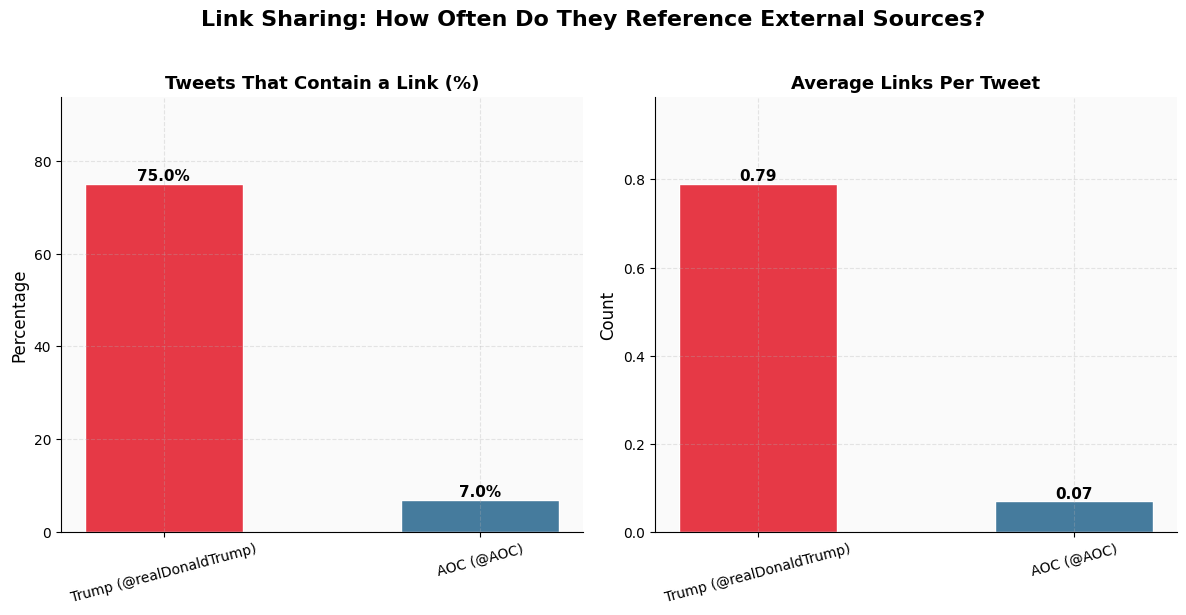


Link Sharing Summary:
  Trump (@realDonaldTrump): 75 out of 100 tweets contain links (75.0%), average=0.79, most in one tweet=2
  AOC (@AOC): 7 out of 100 tweets contain links (7.0%), average=0.07, most in one tweet=1


In [10]:
# --- How often do they share links? ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE)

users = ['trump', 'aoc']
user_labels = [get_user_label(u) for u in users]

# 1. What percentage of tweets contain a link?
ax = axes[0]
url_pcts = [(df[df['user'] == u]['url_count'] > 0).mean() * 100 for u in users]
bars = ax.bar(user_labels, url_pcts, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, url_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Tweets That Contain a Link (%)', fontweight='bold', fontsize=13)
ax.set_ylabel('Percentage')
ax.set_ylim(0, max(url_pcts) * 1.25 if max(url_pcts) > 0 else 10)
ax.tick_params(axis='x', rotation=15)

# 2. Average number of links per tweet
ax = axes[1]
url_means = [df[df['user'] == u]['url_count'].mean() for u in users]
bars = ax.bar(user_labels, url_means, color=[colors[u] for u in users],
              width=0.5, edgecolor='white')
for bar, val in zip(bars, url_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{val:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('Average Links Per Tweet', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_ylim(0, max(url_means) * 1.25 if max(url_means) > 0 else 1)
ax.tick_params(axis='x', rotation=15)

fig.suptitle('Link Sharing: How Often Do They Reference External Sources?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("\nLink Sharing Summary:")
for u in users:
    user_data = df[df['user'] == u]
    total = len(user_data)
    with_url = (user_data['url_count'] > 0).sum()
    mean_urls = user_data['url_count'].mean()
    max_urls = user_data['url_count'].max()
    print(f"  {get_user_label(u)}: {with_url} out of {total} tweets contain links "
          f"({with_url/total*100:.1f}%), average={mean_urls:.2f}, most in one tweet={max_urls}")

**What does this tell us?**

A politician who frequently shares links is curating their audience's information diet — directing them to news articles, videos, or resources. A politician who rarely shares links prefers to be the primary voice, making direct statements rather than pointing elsewhere.

In netnographic terms, this reflects different **information gatekeeping** strategies. The link-heavy approach says "here is what you should read," while the direct-statement approach says "here is what I think."

---
## 5. Who Do They Mention? Mapping Their Political Networks

When a politician mentions another person using @username, they are performing a public act of acknowledgment. Mentions can be:
- **Allies:** Promoting or thanking supporters
- **Opponents:** Calling out or criticizing adversaries
- **Institutions:** Referencing organizations, media outlets, or government bodies

The pattern of mentions reveals each politician's perceived political landscape — who matters to them, who they engage with, and who they target.

**Key term:**
- **Mention (@):** When someone includes @username in their tweet, it creates a direct reference to that person's account. The mentioned person gets notified, and readers can click through to their profile.

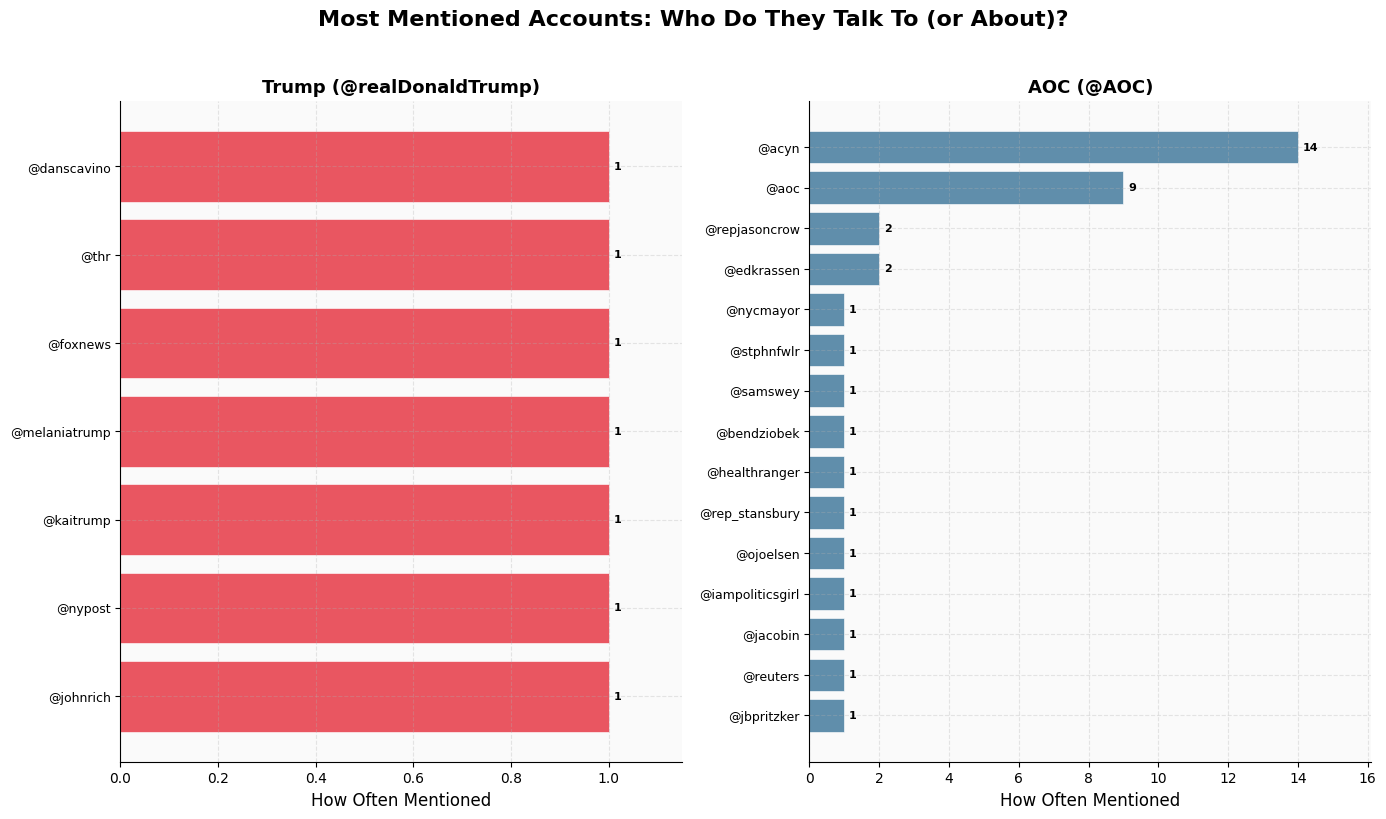

In [11]:
# --- Who do they mention most? (Top 15 accounts) ---

fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_LARGE)

for idx, user in enumerate(['trump', 'aoc']):
    ax = axes[idx]
    user_texts = df[df['user'] == user]['text'].dropna().tolist()

    # Extract all mentions
    all_mentions = []
    for text in user_texts:
        mentions = extract_mentions(text)
        all_mentions.extend([m.lower() for m in mentions])

    # Count and get top 15
    mention_counts = Counter(all_mentions).most_common(15)

    if mention_counts:
        accounts, counts = zip(*reversed(mention_counts))
        y_pos = np.arange(len(accounts))

        ax.barh(y_pos, counts, color=colors[user], alpha=0.85,
                edgecolor='white', linewidth=0.5)
        ax.set_yticks(y_pos)
        ax.set_yticklabels([f'@{a}' for a in accounts], fontsize=9)

        for i, count in enumerate(counts):
            ax.text(count + max(counts) * 0.01, i, str(count),
                    va='center', fontsize=8, fontweight='bold')

        ax.set_xlim(0, max(counts) * 1.15)
    else:
        ax.text(0.5, 0.5, 'No mentions found',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)

    ax.set_title(f'{get_user_label(user)}', fontweight='bold', fontsize=13)
    ax.set_xlabel('How Often Mentioned')

fig.suptitle('Most Mentioned Accounts: Who Do They Talk To (or About)?',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**What does this tell us?**

Look at each politician's top mentions list:
- Are they mentioning **media outlets** (e.g., @FoxNews, @CNN)? This suggests they are engaging with or responding to news coverage.
- Are they mentioning **fellow politicians**? Allies or opponents?
- Are they mentioning **their own accounts** or organizations they lead? This is self-promotion.

The people you mention publicly reveal who you consider important enough to acknowledge — whether as friend or foe.

In [12]:
# --- Do they mention each other? Cross-references between Trump and AOC ---

print("=" * 70)
print("DO THEY MENTION EACH OTHER?")
print("=" * 70)

# Trump mentioning AOC
trump_texts = df[df['user'] == 'trump']['text'].dropna()
trump_mentions_aoc = trump_texts.str.lower().str.contains('aoc|ocasio|alexandria', regex=True).sum()
print(f"\nTrump referencing AOC (tweets containing 'aoc', 'ocasio', or 'alexandria'):")
print(f"  Found in: {trump_mentions_aoc} out of {len(trump_texts)} tweets")
if trump_mentions_aoc > 0:
    aoc_mention_tweets = df[(df['user'] == 'trump') & 
                            df['text'].str.lower().str.contains('aoc|ocasio|alexandria', regex=True, na=False)]
    print("  Examples:")
    for _, row in aoc_mention_tweets.iterrows():
        preview = row['text'][:120] + '...' if len(str(row['text'])) > 120 else row['text']
        print(f"    - {preview}")

# AOC mentioning Trump
aoc_texts = df[df['user'] == 'aoc']['text'].dropna()
aoc_mentions_trump = aoc_texts.str.lower().str.contains('trump|donald', regex=True).sum()
print(f"\nAOC referencing Trump (tweets containing 'trump' or 'donald'):")
print(f"  Found in: {aoc_mentions_trump} out of {len(aoc_texts)} tweets")
if aoc_mentions_trump > 0:
    trump_mention_tweets = df[(df['user'] == 'aoc') & 
                              df['text'].str.lower().str.contains('trump|donald', regex=True, na=False)]
    print("  Examples:")
    for _, row in trump_mention_tweets.head(10).iterrows():
        preview = row['text'][:120] + '...' if len(str(row['text'])) > 120 else row['text']
        print(f"    - {preview}")
    if len(trump_mention_tweets) > 10:
        print(f"    ... and {len(trump_mention_tweets) - 10} more")

print(f"\n--- Summary ---")
print(f"Trump references to AOC: {trump_mentions_aoc} ({trump_mentions_aoc/len(trump_texts)*100:.1f}% of tweets)")
print(f"AOC references to Trump: {aoc_mentions_trump} ({aoc_mentions_trump/len(aoc_texts)*100:.1f}% of tweets)")
print(f"\nThis tells us who pays more attention to the other in their public messaging.")

DO THEY MENTION EACH OTHER?

Trump referencing AOC (tweets containing 'aoc', 'ocasio', or 'alexandria'):
  Found in: 0 out of 100 tweets

AOC referencing Trump (tweets containing 'trump' or 'donald'):
  Found in: 7 out of 100 tweets
  Examples:
    - RT @samswey: 1% of people arrested by ICE have been accused of sexual assault while 24% of Trump’s Cabinet, including Tr...
    - RT @HealthRanger: Trump just declared, "glyphosate-based herbicides are a cornerstone of this Nation’s agricultural prod...
    - From Orbán to Trump, the rise of far-right movements is tightly coordinated and transcends borders.

So too should be ou...
    - It is not a coincidence that after days of President Trump and VP Vance putting Rep. Omar in their crosshairs with sland...
    - RT @EdKrassen: BREAKING:  @AOC just completely went off on Trump after ICE murdered Alex Pretti.  

"Donald Trump [is] a...
    - RT @MarkWarner: Trump’s endless empowerment of federal immigration agents has resulted in yet anoth

**What does this tell us?**

Cross-mention analysis reveals the power dynamics between these two politicians. The one who mentions the other more frequently is, in a sense, giving the other person more visibility and significance. In political communication, naming someone — even to attack them — acknowledges their relevance.

An asymmetry (one mentions the other far more) can suggest that one politician views the other as a useful foil for rallying their base, while the other may not consider them worth engaging with directly.

---
## 6. Topic Breakdown: What Issues Do They Focus On?

Now we categorize each tweet by topic using a keyword-based approach. This means we search each tweet for words related to broad categories like "Economy," "Immigration," "Healthcare," etc. If a tweet contains words like "jobs," "tax," or "inflation," we label it as being about the economy.

**Important caveat:** This is a simplified method. A tweet might talk about the economy in a way that does not use any of our keywords, or a keyword might appear in a different context. Think of this as a "first approximation" — a broad overview rather than a precise classification.

**Why this matters:** The topics a politician chooses to tweet about reveal their strategic priorities. Do they focus on economic issues? Social justice? Attacks on opponents? The distribution of topics is a map of each politician's agenda.

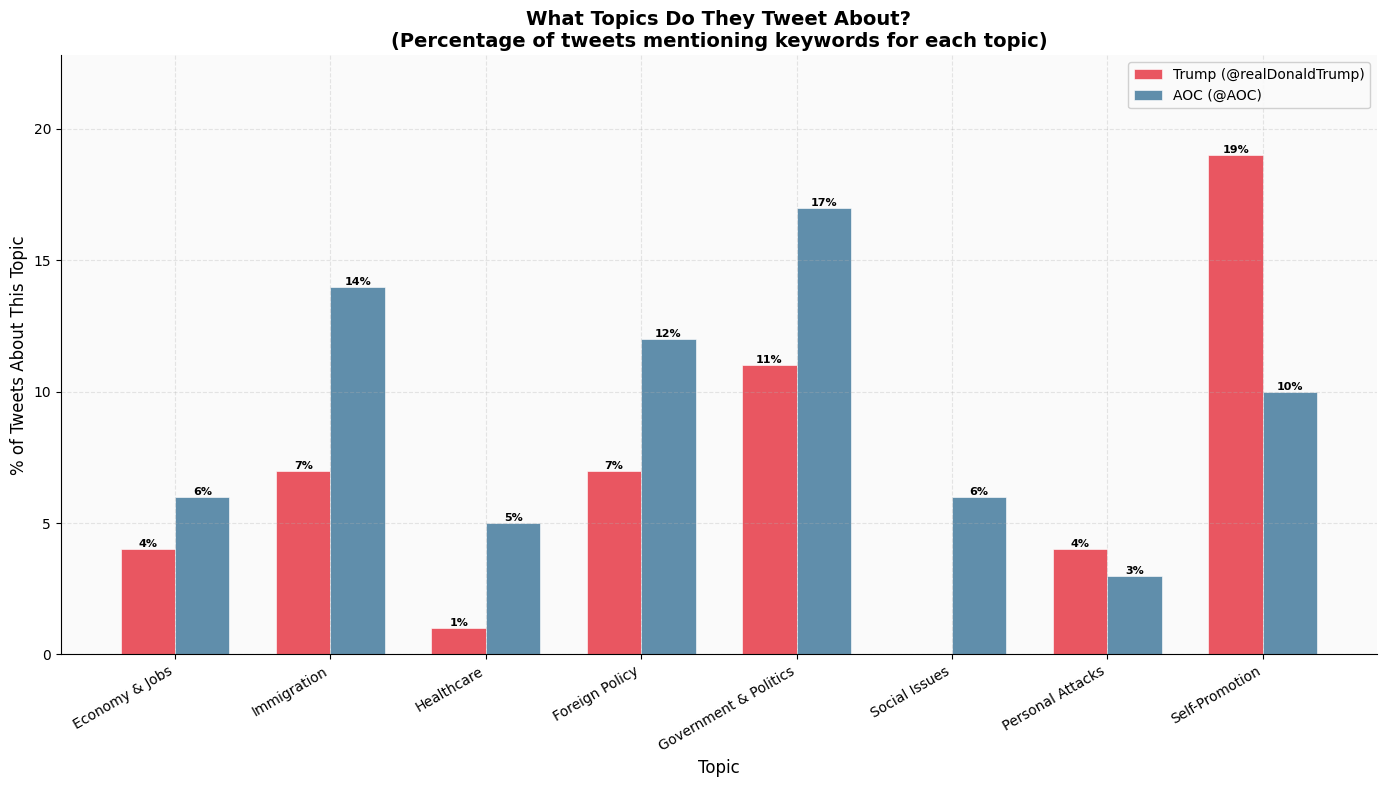


Topic Breakdown (% of tweets about each topic):
------------------------------------------------------------
Topic                       Trump        AOC   Difference
------------------------------------------------------------
Economy & Jobs               4.0%       6.0%       -2.0pp (similar)
Immigration                  7.0%      14.0%       -7.0pp (AOC more)
Healthcare                   1.0%       5.0%       -4.0pp (AOC more)
Foreign Policy               7.0%      12.0%       -5.0pp (AOC more)
Government & Politics       11.0%      17.0%       -6.0pp (AOC more)
Social Issues                0.0%       6.0%       -6.0pp (AOC more)
Personal Attacks             4.0%       3.0%       +1.0pp (similar)
Self-Promotion              19.0%      10.0%       +9.0pp (Trump more)

Trump (@realDonaldTrump): 32/100 tweets matched at least one topic (32.0%)

AOC (@AOC): 49/100 tweets matched at least one topic (49.0%)


In [13]:
# --- Classify tweets by topic using keyword matching ---

# Define topic keyword lists
topic_keywords = {
    'Economy & Jobs': ['economy', 'jobs', 'tax', 'inflation', 'trade', 'tariff',
                       'business', 'gdp', 'debt', 'market'],
    'Immigration': ['border', 'immigration', 'immigrant', 'deportation', 'ice',
                    'asylum', 'migrant'],
    'Healthcare': ['health', 'healthcare', 'medicare', 'medicaid', 'insurance',
                   'hospital'],
    'Foreign Policy': ['china', 'russia', 'ukraine', 'nato', 'war', 'military',
                       'iran', 'israel'],
    'Government & Politics': ['congress', 'senate', 'house', 'vote', 'election',
                              'democrat', 'republican', 'gop'],
    'Social Issues': ['education', 'climate', 'housing', 'gun', 'abortion',
                      'rights', 'equality', 'justice'],
    'Personal Attacks': ['fake', 'corrupt', 'crooked', 'radical', 'socialist',
                         'fascist', 'liar'],
    'Self-Promotion': ['maga', 'trump', 'great', 'best', 'winning', 'deal'],
}

# Classify each tweet (a tweet can belong to multiple topics)
for topic, keywords in topic_keywords.items():
    col_name = f'topic_{topic.lower().replace("/", "_").replace(" ", "_").replace("&", "and")}'
    pattern = '|'.join(keywords)
    df[col_name] = df['text'].str.lower().str.contains(pattern, regex=True, na=False)

# Calculate what percentage of each politician's tweets fall into each topic
topic_cols = [c for c in df.columns if c.startswith('topic_')]
topic_display_names = list(topic_keywords.keys())

topic_data = {}
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    total = len(user_df)
    pcts = []
    for col in topic_cols:
        pct = user_df[col].sum() / total * 100
        pcts.append(pct)
    topic_data[user] = pcts

# Grouped bar chart
fig, ax = plt.subplots(figsize=FIGURE_SIZE_LARGE)

x = np.arange(len(topic_display_names))
bar_width = 0.35

for i, user in enumerate(['trump', 'aoc']):
    offset = -bar_width / 2 + i * bar_width
    bars = ax.bar(x + offset, topic_data[user], bar_width,
                  label=get_user_label(user), color=colors[user],
                  alpha=0.85, edgecolor='white', linewidth=0.5)

    # Add value labels on bars
    for bar, val in zip(bars, topic_data[user]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{val:.0f}%', ha='center', va='bottom',
                    fontsize=8, fontweight='bold')

ax.set_title('What Topics Do They Tweet About?\n(Percentage of tweets mentioning keywords for each topic)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Topic')
ax.set_ylabel('% of Tweets About This Topic')
ax.set_xticks(x)
ax.set_xticklabels(topic_display_names, rotation=30, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(topic_data['trump']), max(topic_data['aoc'])) * 1.2 if 
            max(max(topic_data['trump']), max(topic_data['aoc'])) > 0 else 10)
plt.tight_layout()
plt.show()

# Print detailed table
print("\nTopic Breakdown (% of tweets about each topic):")
print("-" * 60)
print(f"{'Topic':<22} {'Trump':>10} {'AOC':>10} {'Difference':>12}")
print("-" * 60)
for topic, trump_pct, aoc_pct in zip(topic_display_names,
                                      topic_data['trump'],
                                      topic_data['aoc']):
    diff = trump_pct - aoc_pct
    arrow = '(Trump more)' if diff > 2 else '(AOC more)' if diff < -2 else '(similar)'
    print(f"{topic:<22} {trump_pct:>9.1f}% {aoc_pct:>9.1f}% {diff:>+10.1f}pp {arrow}")

# Coverage check: how many tweets matched at least one topic?
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    any_topic = user_df[topic_cols].any(axis=1).sum()
    print(f"\n{get_user_label(user)}: {any_topic}/{len(user_df)} tweets matched at least one topic ({any_topic/len(user_df)*100:.1f}%)")

**What does this tell us?**

The topic chart is like a menu of each politician's priorities. Where the bars are tallest is where they spend most of their public attention. Notice:

- **Which topics are shared?** If both politicians talk a lot about the same topic, they are competing over the same issue space — but likely framing it very differently.
- **Which topics are dominated by one person?** These are "owned" issues — topics that one politician has claimed as their territory.
- **Personal Attacks vs. Policy:** The balance between attacking opponents and discussing actual policy reveals a lot about each politician's strategy.

Remember: a tweet can match multiple topics, so the percentages do not add up to 100%.

---
## 7. Tweet Map: A Bird's-Eye View of What Each Politician Discusses

Imagine an AI reads every single tweet and understands its meaning. It then places each tweet on a map — tweets about similar topics end up close together, while tweets about different topics are far apart. This lets us literally *see* the difference in what Trump and AOC talk about.

**How does this work?**

1. An AI model (OpenAI's text embedding model) reads each tweet and converts it into a long list of numbers that represent its meaning. Think of it as the AI's "understanding" of each tweet, expressed as coordinates in a very high-dimensional space (1,536 dimensions!).
2. Since we cannot visualize 1,536 dimensions, we use a technique called **PCA (Principal Component Analysis)** to compress those 1,536 dimensions down to just 2 — an X axis and a Y axis — while preserving as much of the original structure as possible.
3. We then plot each tweet as a dot on this 2D map, colored by politician.

**Key terms:**
- **Embedding:** A list of numbers that captures the meaning of a piece of text. Similar texts have similar numbers.
- **PCA (Principal Component Analysis):** A method to simplify high-dimensional data into fewer dimensions while keeping the most important patterns. Think of it like compressing a 3D globe into a 2D map — you lose some detail but can still see the big picture.
- **Cluster:** A group of dots close together on the map, meaning those tweets are about similar things.

In [14]:
# --- Generate embeddings (or load cached) ---

import json
import os
from pathlib import Path
from openai import OpenAI
from sklearn.decomposition import PCA

# Check for cached embeddings first
embeddings_path = Path('../../data/processed/embeddings.json')
texts = df['text'].fillna('').tolist()

if embeddings_path.exists():
    print("Loading cached embeddings...")
    with open(embeddings_path, 'r') as f:
        embeddings_data = json.load(f)
    embeddings = embeddings_data['embeddings']
else:
    print("Generating embeddings with OpenAI (this only runs once)...")
    from dotenv import load_dotenv
    load_dotenv('../../.env')
    client_openai = OpenAI()
    
    response = client_openai.embeddings.create(
        input=texts,
        model='text-embedding-3-small'
    )
    embeddings = [r.embedding for r in response.data]
    
    # Cache for future runs
    embeddings_path.parent.mkdir(parents=True, exist_ok=True)
    with open(embeddings_path, 'w') as f:
        json.dump({'embeddings': embeddings, 'model': 'text-embedding-3-small'}, f)
    print(f"Embeddings cached to {embeddings_path}")

print(f"Loaded {len(embeddings)} embeddings, each with {len(embeddings[0])} dimensions")

Generating embeddings with OpenAI (this only runs once)...


Embeddings cached to ..\..\data\processed\embeddings.json
Loaded 200 embeddings, each with 1536 dimensions


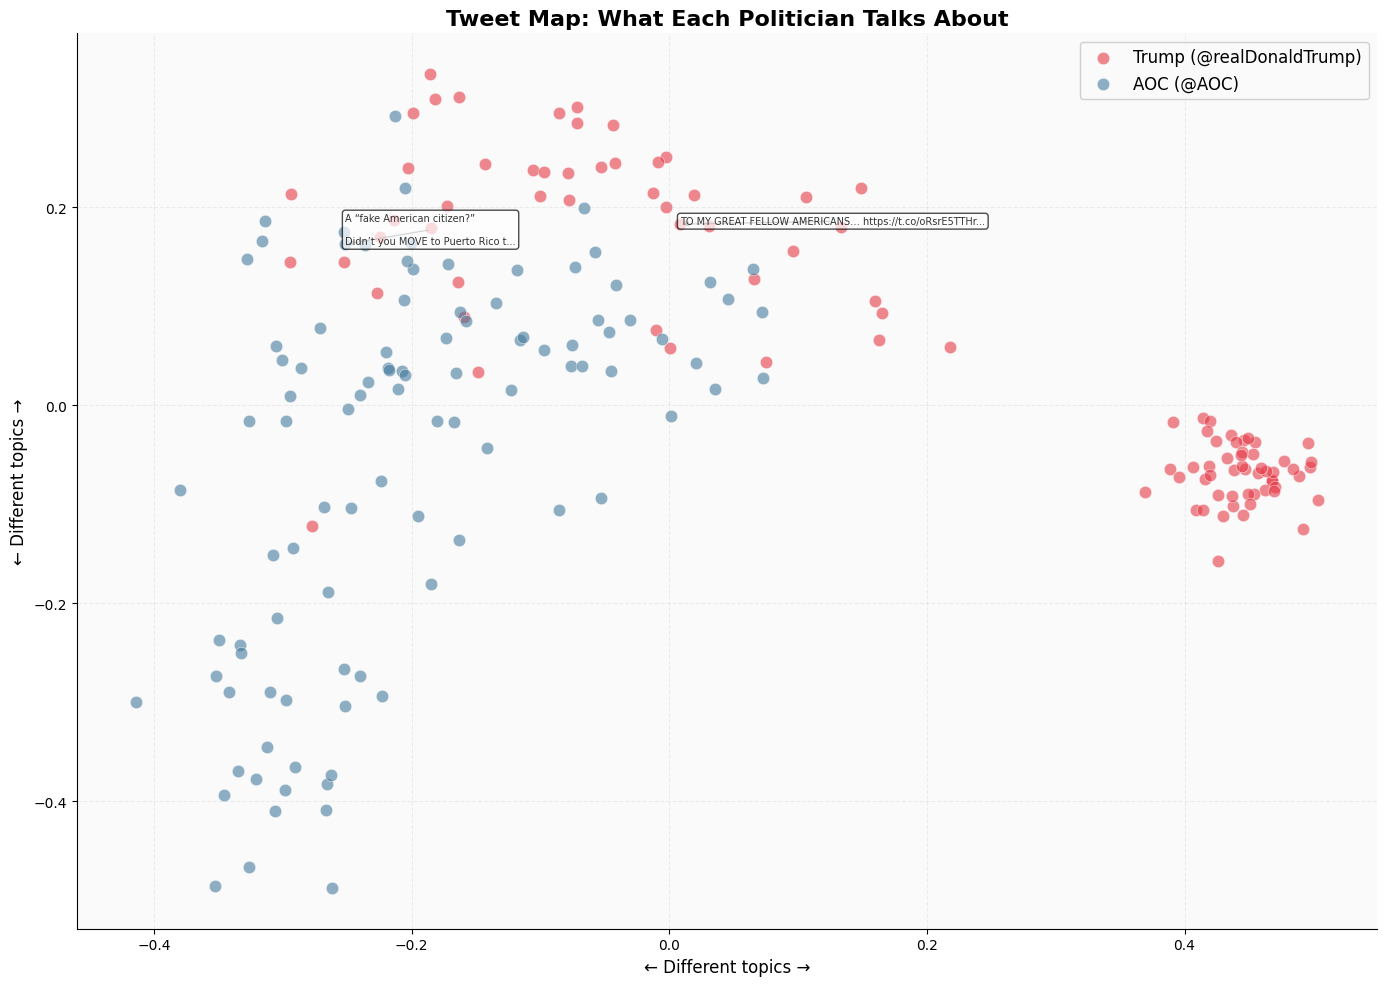

In [15]:
# --- Create the 2D Tweet Map ---

import numpy as np

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(np.array(embeddings))

fig, ax = plt.subplots(figsize=(14, 10))

for user in ['trump', 'aoc']:
    mask = df['user'] == user
    ax.scatter(
        coords[mask.values, 0], coords[mask.values, 1],
        c=colors[user], label=get_user_label(user),
        alpha=0.6, s=80, edgecolors='white', linewidth=0.5
    )

# Annotate a few tweets for context
for user in ['trump', 'aoc']:
    user_df = df[df['user'] == user]
    # Annotate the highest-engagement tweet
    top_idx = user_df['total_engagement'].idxmax()
    pos = df.index.get_loc(top_idx)
    text_snippet = df.loc[top_idx, 'text'][:60] + '...'
    ax.annotate(text_snippet, (coords[pos, 0], coords[pos, 1]),
                fontsize=7, alpha=0.8,
                arrowprops=dict(arrowstyle='->', alpha=0.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

ax.set_title("Tweet Map: What Each Politician Talks About", fontsize=16, fontweight='bold')
ax.set_xlabel("\u2190 Different topics \u2192", fontsize=12)
ax.set_ylabel("\u2190 Different topics \u2192", fontsize=12)
ax.legend(fontsize=12, loc='upper right')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

**What does this tell us?**

Look at where the dots cluster. If Trump's dots (red) are concentrated in one area and AOC's dots (blue) in another, it means they talk about fundamentally different things. If they overlap, they share common topics but may approach them differently. The AI captures not just keywords but the *meaning* of what is being said.

**How to read this map:**
- **Separate clusters** = different topic worlds. These politicians are talking past each other.
- **Overlapping areas** = shared topics. Even within overlap, look for subtle separations — they may discuss the same issue from opposing angles.
- **Outlier dots** (far from any cluster) = unusual or unique tweets that do not fit either politician's normal pattern.
- **Tight clusters** = repetitive messaging on the same themes. **Spread-out dots** = a wider range of topics.

This is one of the most powerful netnographic tools: being able to literally visualize the "distance" between two political worldviews.

---
## 8. Putting It All Together: Digital Identity Comparison

Now we bring together everything we have learned — writing style, vocabulary, hashtags, mentions, topics, and the tweet map — into a single summary. This comparison table is a composite profile of each politician's **digital identity**: the persona they project through their tweet content and composition.

**What is digital identity?** In netnography, digital identity refers to the version of yourself that you present online. It is constructed through every choice: the words you use, the people you mention, the hashtags you deploy, and the topics you prioritize. It may or may not match someone's "real" personality — but it is the version that reaches millions of followers.

In [16]:
# --- Digital identity comparison table ---

def get_top_topic(user):
    """Get the most common topic for a user."""
    user_df = df[df['user'] == user]
    topic_pcts = {}
    for col, name in zip(topic_cols, topic_display_names):
        topic_pcts[name] = user_df[col].sum()
    if topic_pcts:
        return max(topic_pcts, key=topic_pcts.get)
    return 'N/A'

def get_hashtag_strategy(user):
    """Describe hashtag usage pattern in plain English."""
    user_df = df[df['user'] == user]
    pct_with = (user_df['hashtag_count'] > 0).mean() * 100
    mean_count = user_df['hashtag_count'].mean()
    if pct_with < 10:
        return f'Rarely uses hashtags ({pct_with:.0f}% of tweets, {mean_count:.1f} avg)'
    elif pct_with < 40:
        return f'Sometimes uses hashtags ({pct_with:.0f}% of tweets, {mean_count:.1f} avg)'
    else:
        return f'Heavy hashtag user ({pct_with:.0f}% of tweets, {mean_count:.1f} avg)'

def get_tone_descriptor(user):
    """Describe primary tone based on writing style markers."""
    user_df = df[df['user'] == user]
    caps = user_df['caps_ratio'].mean()
    excl = user_df['exclamation_count'].mean()
    quest = user_df['question_count'].mean()
    parts = []
    if caps > 0.3:
        parts.append('Intense (lots of ALL CAPS)')
    elif caps > 0.15:
        parts.append('Somewhat emphatic')
    else:
        parts.append('Standard writing style')
    if excl > 1.0:
        parts.append('heavy use of exclamation marks')
    if quest > 0.5:
        parts.append('asks questions often')
    return ', '.join(parts)

def get_media_preference(user):
    """Describe media usage pattern."""
    user_df = df[df['user'] == user]
    media_dist = user_df['media_type'].value_counts(normalize=True)
    top_type = media_dist.index[0] if len(media_dist) > 0 else 'none'
    top_pct = media_dist.values[0] * 100 if len(media_dist) > 0 else 0
    return f'Mostly {top_type.lower()} ({top_pct:.0f}%)'

def get_engagement_style(user):
    """Describe how they interact with others."""
    user_df = df[df['user'] == user]
    mention_rate = user_df['mention_count'].mean()
    reply_pct = user_df['is_reply'].mean() * 100
    quote_pct = user_df['is_quote'].mean() * 100
    if reply_pct > 20:
        style = 'Conversational (replies a lot)'
    elif quote_pct > 15:
        style = 'Commentary-driven (quotes others)'
    else:
        style = 'Broadcast-style (mostly original posts)'
    return f'{style} — replies: {reply_pct:.0f}%, quotes: {quote_pct:.0f}%'

# Build the comparison table
comparison = {
    'Writing Tone': {
        'Trump': get_tone_descriptor('trump'),
        'AOC': get_tone_descriptor('aoc')
    },
    'Main Topic Focus': {
        'Trump': get_top_topic('trump'),
        'AOC': get_top_topic('aoc')
    },
    'Average Tweet Length': {
        'Trump': f"{df[df['user']=='trump']['text_length'].mean():.0f} characters / {df[df['user']=='trump']['word_count'].mean():.0f} words",
        'AOC': f"{df[df['user']=='aoc']['text_length'].mean():.0f} characters / {df[df['user']=='aoc']['word_count'].mean():.0f} words"
    },
    'Hashtag Strategy': {
        'Trump': get_hashtag_strategy('trump'),
        'AOC': get_hashtag_strategy('aoc')
    },
    'Media Preference': {
        'Trump': get_media_preference('trump'),
        'AOC': get_media_preference('aoc')
    },
    'Link Sharing': {
        'Trump': f"{(df[df['user']=='trump']['url_count']>0).mean()*100:.0f}% of tweets contain links",
        'AOC': f"{(df[df['user']=='aoc']['url_count']>0).mean()*100:.0f}% of tweets contain links"
    },
    'Emoji Usage': {
        'Trump': f"{df[df['user']=='trump']['has_emoji'].mean()*100:.0f}% of tweets",
        'AOC': f"{df[df['user']=='aoc']['has_emoji'].mean()*100:.0f}% of tweets"
    },
    'Interaction Style': {
        'Trump': get_engagement_style('trump'),
        'AOC': get_engagement_style('aoc')
    },
}

comparison_df = pd.DataFrame(comparison).T
comparison_df.index.name = 'Dimension'

# Display styled table
styled = comparison_df.style.set_caption(
    'Digital Identity Comparison: Trump vs AOC'
).set_table_styles([
    {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold'), ('margin-bottom', '10px')]},
    {'selector': 'th', 'props': [('background-color', '#f0f0f0'), ('font-weight', 'bold'), ('text-align', 'center'), ('padding', '8px')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('padding', '8px'), ('max-width', '300px')]},
    {'selector': 'th.row_heading', 'props': [('text-align', 'left'), ('font-weight', 'bold')]},
]).set_properties(
    subset=['Trump'], **{'background-color': '#fce4e4'}
).set_properties(
    subset=['AOC'], **{'background-color': '#e4ecf4'}
)

display(styled)

# Also print plain text version
print("\nPlain text version:")
print("=" * 90)
print(f"{'Dimension':<22} {'Trump':<34} {'AOC':<34}")
print("=" * 90)
for dim, values in comparison.items():
    trump_val = values['Trump'][:32]
    aoc_val = values['AOC'][:32]
    print(f"{dim:<22} {trump_val:<34} {aoc_val:<34}")

,Trump,AOC
Dimension,,
Writing Tone,Somewhat emphatic,Standard writing style
Main Topic Focus,Self-Promotion,Government & Politics
Average Tweet Length,102 characters / 14 words,153 characters / 25 words
Hashtag Strategy,"Rarely uses hashtags (1% of tweets, 0.0 avg)","Rarely uses hashtags (2% of tweets, 0.0 avg)"
Media Preference,Mostly none (41%),Mostly none (95%)
Link Sharing,75% of tweets contain links,7% of tweets contain links
Emoji Usage,5% of tweets,7% of tweets
Interaction Style,"Broadcast-style (mostly original posts) — replies: 0%, quotes: 3%","Commentary-driven (quotes others) — replies: 0%, quotes: 37%"



Plain text version:
Dimension              Trump                              AOC                               
Writing Tone           Somewhat emphatic                  Standard writing style            
Main Topic Focus       Self-Promotion                     Government & Politics             
Average Tweet Length   102 characters / 14 words          153 characters / 25 words         
Hashtag Strategy       Rarely uses hashtags (1% of twee   Rarely uses hashtags (2% of twee  
Media Preference       Mostly none (41%)                  Mostly none (95%)                 
Link Sharing           75% of tweets contain links        7% of tweets contain links        
Emoji Usage            5% of tweets                       7% of tweets                      
Interaction Style      Broadcast-style (mostly original   Commentary-driven (quotes others  


**What does this tell us?**

This summary table is your "cheat sheet" for comparing Trump and AOC's online communication strategies. Each row captures a different dimension of their digital identity. Together, they paint a picture of two very different approaches to political communication on social media.

Remember: these are the personas they *choose* to project. Every element — from writing style to topic focus — is a strategic decision (conscious or not) about how to connect with their audience.

---
## 9. Key Takeaways

Here are the most important findings from this content analysis:

**Writing Style and Tone:**
1. Trump and AOC have distinctly different writing styles that reflect their communication strategies. Differences in tweet length, capitalization, and punctuation are not random — they are consistent patterns that define each politician's digital "voice." A more emphatic, exclamatory style aims to convey urgency and strength, while a more measured style signals thoughtfulness and policy focus.

2. The use of ALL CAPS and exclamation marks serves as a form of digital "volume control." Politicians who use these features more heavily are effectively shouting in a crowded room — demanding attention through typographic intensity rather than (or in addition to) substantive arguments.

**Vocabulary and Word Choice:**
3. Each politician has a distinctive vocabulary — a set of "signature words" that they use far more than the other. These words function as ideological markers, revealing each person's priorities and the narrative they want to construct. Vocabulary choice is one of the most revealing aspects of digital identity.

4. The overlap (or lack thereof) in their most common words tells us whether these politicians are engaged in the same conversation or speaking to entirely different audiences about different concerns.

**Hashtags as Identity and Strategy:**
5. Hashtag usage reveals fundamentally different approaches to online mobilization. Whether a politician uses hashtags as personal branding (e.g., turning their name into a movement), issue advocacy, or community building reflects their theory of how political power works on social media.

**Topic Focus and the Tweet Map:**
6. The keyword-based topic analysis and the AI-powered tweet map both confirm that Trump and AOC occupy different thematic territories. Their topic emphasis reveals not just what they care about, but what they want their audiences to care about — a key mechanism of political agenda-setting.

**Cross-References and Power Dynamics:**
7. The asymmetry (or symmetry) in how often they reference each other reveals the political relationship between them. Mentioning an opponent gives them visibility; ignoring them denies them relevance. This is a strategic calculation that shapes the broader political discourse.

---

*Note on methods: The keyword-based topic classification and word counting used in this notebook provide a useful quantitative overview but are simplified approaches. They should be complemented with close reading of individual tweets to capture nuance, sarcasm, context, and meaning that automated methods may miss. The AI-powered tweet map (embedding + PCA) captures deeper semantic meaning but is still an approximation — reducing 1,536 dimensions to 2 inevitably loses some information.*

### Next Steps
- **Notebook 4**: Network and interaction analysis — examining who replies to whom, audience composition, and conversational patterns
- **Notebook 5**: Synthesis and comparative netnographic interpretation — bringing all findings together into a coherent narrative